**Annual count of impacting (100km ring) and landfall TCs over PH. 7 categories:**

1.   TD + TS
1.   CAT 1
1.   CAT 2
1.   CAT 3
2.   CAT 4
2.   CAT 5
2.   CAT 1 - 3
1.   CAT 4 - 5

In [61]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

In [62]:
tc_points = gpd.read_file("IBTrACS.WP.list.v04r01.points.shp")
lines = gpd.read_file("IBTrACS.WP.list.v04r01.lines.shp")
phl_buffer = gpd.read_file("PHL_1degree_buffer.shp")
phl_land = gpd.read_file("PHL_adm0.shp")

In [63]:
tc_points = tc_points[(tc_points['SEASON'] >= 1980) & (tc_points['SEASON'] <= 2024)]

In [64]:
def categorize_tc(wind):
    if pd.isna(wind):
        return None
    if wind >= 137:
        return 'Category 5'
    elif wind >= 113:
        return 'Category 4'
    elif wind >= 96:
        return 'Category 3'
    elif wind >= 83:
        return 'Category 2'
    elif wind >= 64:
        return 'Category 1'
    elif wind > 34:
        return 'Tropical Storm'
    return 'Tropical depression'

In [65]:
tc_points['category'] = tc_points['USA_WIND'].apply(categorize_tc)

In [66]:
tc_points = tc_points.to_crs(epsg=4326)
phl_buffer = phl_buffer.to_crs(epsg=4326)
phl_land = phl_land.to_crs(epsg=4326)

In [67]:
impacting_points = gpd.sjoin(tc_points, phl_buffer[['geometry']], how='inner', predicate='within')
landfall_points = gpd.sjoin(tc_points, phl_land[['geometry']], how='inner', predicate='intersects')


In [68]:
def get_max_category(group):
    categories = ['Category 5','Category 4','Category 3','Category 2','Category 1','Tropical Storm','Tropical depression']
    for cat in categories:
        if cat in group['category'].values:
            return cat

In [69]:
# Impacting TCs
impacting_tcs = impacting_points.groupby(['SID', 'year']).apply(get_max_category).reset_index().rename(columns={0: 'category'})
impacting_tcs = impacting_tcs[impacting_tcs['category'].notnull()]
impacting_counts = impacting_tcs.groupby(['year', 'category']).size().unstack(fill_value=0)

# Landfall TCs
landfall_tcs = landfall_points.groupby(['SID', 'year']).apply(get_max_category).reset_index().rename(columns={0: 'category'})
landfall_tcs = landfall_tcs[landfall_tcs['category'].notnull()]
landfall_counts = landfall_tcs.groupby(['year', 'category']).size().unstack(fill_value=0)


In [70]:
landfall_tcs

,SID,year,category
0,1980076N06148,1980,Tropical depression
1,1980137N04158,1980,Tropical Storm
2,1980171N06142,1980,Tropical depression
4,1980197N07154,1980,Category 1
5,1980197N15133,1980,Tropical depression
...,...,...,...
326,2024245N12129,2024,Tropical Storm
328,2024293N13141,2024,Tropical Storm
329,2024313N10169,2024,Category 3
330,2024313N15138,2024,Category 1


In [99]:
duplicate_sids_landfall = landfall_tcs[landfall_tcs['SID'].duplicated(keep=False)]

if not duplicate_sids_landfall.empty:
    print("Duplicate SIDs found:")
    print(duplicate_sids_landfall[['SID', 'year', 'category']].sort_values(by='SID'))
    print(f"\nTotal number of duplicate landfall_tcs SID entries: {len(duplicate_sids_landfall)}")
else:
    print("No duplicate SIDs found in the DataFrame.")

No duplicate SIDs found in the DataFrame.


In [100]:
duplicate_sids_impacting = impacting_tcs[impacting_tcs['SID'].duplicated(keep=False)]

if not duplicate_sids_impacting.empty:
    print("Duplicate SIDs found:")
    print(duplicate_sids_impacting[['SID', 'year', 'category']].sort_values(by='SID'))
    print(f"\nTotal number of duplicate impacting_tcs SID entries: {len(duplicate_sids_impacting)}")
else:
    print("No duplicate SIDs found in the DataFrame.")

Duplicate SIDs found:
              SID  year             category
71  1986353N03178  1986       Tropical Storm
72  1986353N03178  1987  Tropical depression

Total number of duplicate impacting_tcs SID entries: 2


In [73]:
# Ensure all categories are present
for cat in ['Category 5','Category 4','Category 3','Category 2','Category 1','Tropical Storm','Tropical depression']:
    if cat not in impacting_counts.columns:
        impacting_counts[cat] = 0

# Compute All TCs (sum of Tropical Storm and CAT 1-5 )
impacting_counts['TS + TD'] = impacting_counts[['Tropical Storm','Tropical depression']].sum(axis=1)
landfall_counts['TS + TD']  = landfall_counts[['Tropical Storm','Tropical depression']].sum(axis=1)

impacting_counts['CAT 1'] = impacting_counts[['Category 1',]].sum(axis=1)
landfall_counts['CAT 1'] = landfall_counts[['Category 1',]].sum(axis=1)

impacting_counts['CAT 2'] = impacting_counts[['Category 2',]].sum(axis=1)
landfall_counts['CAT 2'] = landfall_counts[['Category 2',]].sum(axis=1)

impacting_counts['CAT 3'] = impacting_counts[['Category 3',]].sum(axis=1)
landfall_counts['CAT 3'] = landfall_counts[['Category 3',]].sum(axis=1)

impacting_counts['CAT 4'] = impacting_counts[['Category 4']].sum(axis=1)
landfall_counts['CAT 4'] = landfall_counts[['Category 4']].sum(axis=1)

impacting_counts['CAT 5'] = impacting_counts[['Category 5']].sum(axis=1)
landfall_counts['CAT 5'] = landfall_counts[['Category 5']].sum(axis=1)

impacting_counts['CAT 1 - 2'] = impacting_counts[['Category 1','Category 2']].sum(axis=1)
landfall_counts['CAT 1 - 2'] = landfall_counts[['Category 1','Category 2']].sum(axis=1)

impacting_counts['CAT 3 - 5'] = impacting_counts[['Category 3','Category 4','Category 5']].sum(axis=1)
landfall_counts['CAT 3 - 5'] = landfall_counts[['Category 3','Category 4','Category 5']].sum(axis=1)


# Reorder columns
categories = ['TS + TD','CAT 1','CAT 2','CAT 3','CAT 4','CAT 5','CAT 1 - 2','CAT 3 - 5',]
impacting_counts = impacting_counts[categories]
landfall_counts = landfall_counts[categories]

In [74]:
landfall_counts

category,TS + TD,CAT 1,CAT 2,CAT 3,CAT 4,CAT 5,CAT 1 - 2,CAT 3 - 5
year,,,,,,,,
1980,5,1,0,2,0,0,1,2
1981,4,2,0,0,0,0,2,0
1982,5,1,1,1,0,0,2,1
1983,4,1,0,0,0,0,1,0
1984,2,0,0,1,1,0,0,2
1985,1,1,1,0,0,0,2,0
1986,5,1,1,0,0,0,2,0
1987,2,1,1,1,1,1,2,3
1988,5,1,0,1,1,0,1,2


In [75]:
impacting_counts

category,TS + TD,CAT 1,CAT 2,CAT 3,CAT 4,CAT 5,CAT 1 - 2,CAT 3 - 5
year,,,,,,,,
1980,6,0,2,0,2,0,2,2
1981,3,1,1,1,1,0,2,2
1982,3,2,1,2,0,0,3,2
1983,7,1,0,0,1,0,1,1
1984,4,0,1,0,2,0,1,2
1985,2,1,1,0,1,0,2,1
1986,6,1,1,1,0,0,2,1
1987,3,0,2,1,0,2,2,3
1988,6,1,1,1,2,0,2,3


In [76]:
landfall_counts_column_sums = landfall_counts.sum()
result1 = landfall_counts_column_sums / 45
std_devs = landfall_counts.std()

result1 = pd.DataFrame({
    'Sum': landfall_counts_column_sums,
    'Annual mean number': result1,
    'Standard Deviation': std_devs
})

result1

,Sum,Annual mean number,Standard Deviation
category,,,
TS + TD,193,4.288889,2.492007
CAT 1,36,0.800000,0.868646
CAT 2,20,0.444444,0.623610
CAT 3,20,0.444444,0.586033
CAT 4,22,0.488889,0.661342
CAT 5,5,0.111111,0.317821
CAT 1 - 2,56,1.244444,1.069315
CAT 3 - 5,47,1.044444,0.928233


In [77]:
# Save to CSV
result1.to_csv('landfall_counts_average.csv', index_label='Category')

print("CSV file 'landfall_counts_average.csv' has been generated.")

CSV file 'landfall_counts_average.csv' has been generated.


In [78]:
landfall_counts_column_sums

,0
category,
TS + TD,193
CAT 1,36
CAT 2,20
CAT 3,20
CAT 4,22
CAT 5,5
CAT 1 - 2,56
CAT 3 - 5,47


In [79]:
impacting_counts_column_sums = impacting_counts.sum()
result2 = impacting_counts_column_sums / 45
result2

,0
category,
TS + TD,5.800000
CAT 1,0.800000
CAT 2,0.666667
CAT 3,0.466667
CAT 4,0.822222
CAT 5,0.466667
CAT 1 - 2,1.466667
CAT 3 - 5,1.755556


In [80]:
impacting_counts_column_sums

,0
category,
TS + TD,261
CAT 1,36
CAT 2,30
CAT 3,21
CAT 4,37
CAT 5,21
CAT 1 - 2,66
CAT 3 - 5,79


In [81]:
bypassing = impacting_counts_column_sums - landfall_counts_column_sums

In [82]:
bypassing

,0
category,
TS + TD,68
CAT 1,0
CAT 2,10
CAT 3,1
CAT 4,15
CAT 5,16
CAT 1 - 2,10
CAT 3 - 5,32


In [83]:
result3 = bypassing / 45

std_devs1 = bypassing.std()

result3 = pd.DataFrame({
    'Sum': bypassing,
    'Annual mean number': result3,
    'Standard Deviation': std_devs
})


result3

,Sum,Annual mean number,Standard Deviation
category,,,
TS + TD,68,1.511111,2.492007
CAT 1,0,0.000000,0.868646
CAT 2,10,0.222222,0.623610
CAT 3,1,0.022222,0.586033
CAT 4,15,0.333333,0.661342
CAT 5,16,0.355556,0.317821
CAT 1 - 2,10,0.222222,1.069315
CAT 3 - 5,32,0.711111,0.928233


In [84]:

# Save to CSV
result3.to_csv('bypassing_counts_average.csv', index_label='Category')

print("CSV file 'bypassing_counts_average.csv' has been generated.")

CSV file 'bypassing_counts_average.csv' has been generated.


In [85]:
def calculate_slope(years, values):
    coefficients = np.polyfit(years, values, 1)
    return coefficients[0]  # Return slope (m from y = mx + b)


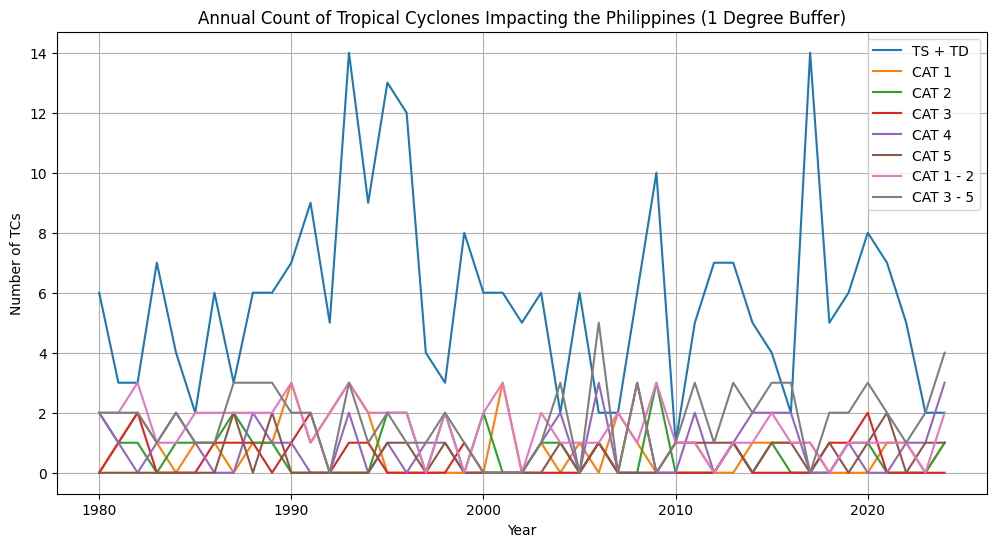

In [86]:
plt.figure(figsize=(12, 6))
for cat in categories:
    plt.plot(impacting_counts.index, impacting_counts[cat], label=cat)
plt.title('Annual Count of Tropical Cyclones Impacting the Philippines (1 Degree Buffer)')
plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()

# Calculate slopes for Plot 2,3,4
slope_ts_td = calculate_slope(impacting_counts.index, impacting_counts['TS + TD'])
slope_cat1_3 = calculate_slope(impacting_counts.index, impacting_counts['CAT 1 - 2'])
slope_cat4_5 = calculate_slope(impacting_counts.index, impacting_counts['CAT 3 - 5'])

# Calculate slopes for Plot 2,3,4
slope_ts_tdA = calculate_slope(landfall_counts.index, landfall_counts['TS + TD'])
slope_cat1_3B = calculate_slope(landfall_counts.index, landfall_counts['CAT 1 - 2'])
slope_cat4_5C = calculate_slope(landfall_counts.index, landfall_counts['CAT 3 - 5'])

In [87]:
print(f"TS + TD slope: {slope_ts_tdA:.3f}")
print(f"cat1-2 slope: {slope_cat1_3B:.3f}")
print(f"cat3-5 slope: {slope_cat4_5C:.3f}")

TS + TD slope: -0.030
cat1-2 slope: -0.025
cat3-5 slope: 0.009


In [88]:
print(f"TS + TD slope: {slope_ts_td:.3f}")

TS + TD slope: -0.016


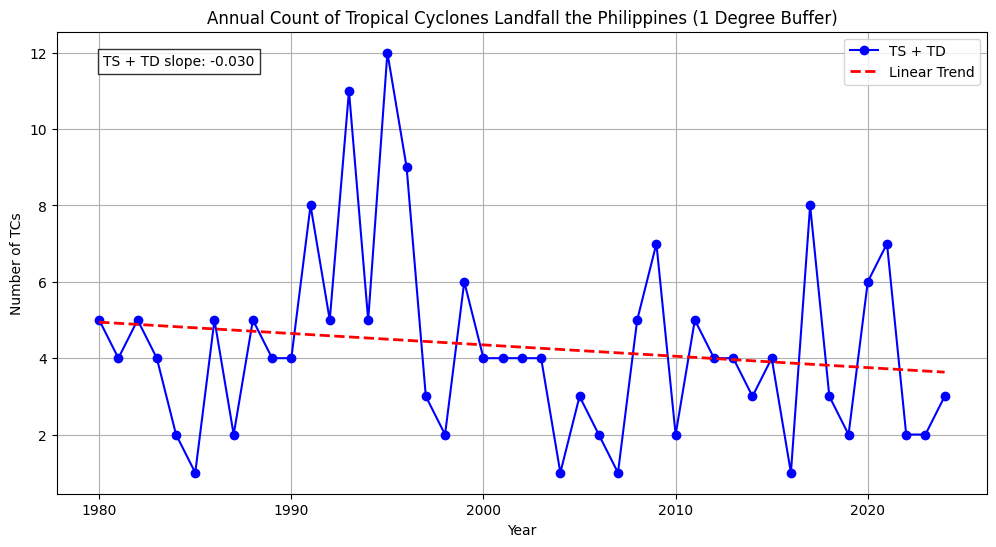

In [89]:
plt.figure(figsize=(12, 6))
plt.plot(landfall_counts.index, landfall_counts['TS + TD'], label='TS + TD', marker='o', color='blue')
plt.title('Annual Count of Tropical Cyclones Landfall the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(landfall_counts.index, landfall_counts['TS + TD'], 1)
p = np.poly1d(z)
plt.plot(landfall_counts.index, p(landfall_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_ts_td = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'TS + TD slope: {slope_ts_tdA:.3f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()


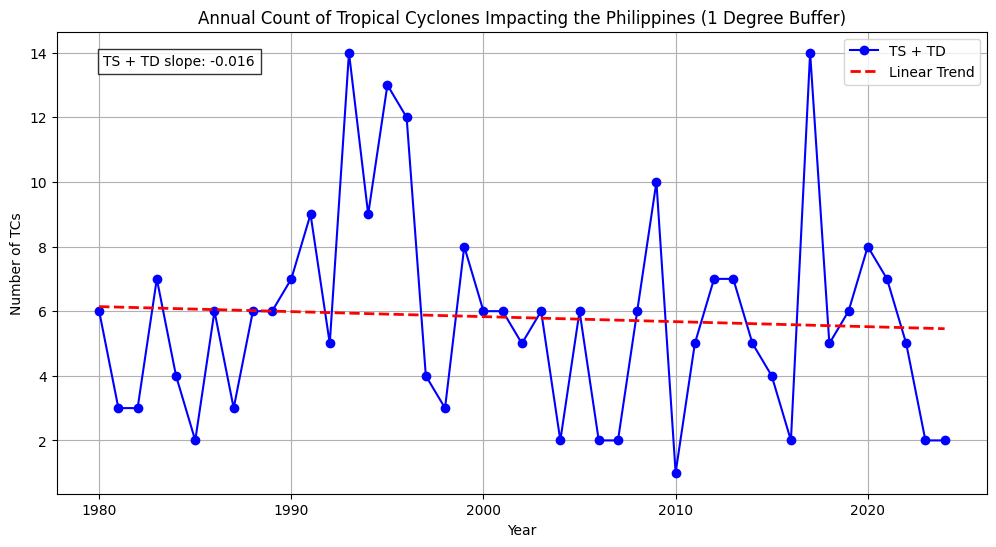

In [90]:
plt.figure(figsize=(12, 6))
plt.plot(impacting_counts.index, impacting_counts['TS + TD'], label='TS + TD', marker='o', color='blue')
plt.title('Annual Count of Tropical Cyclones Impacting the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['TS + TD'], 1)
p = np.poly1d(z)
plt.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_ts_td = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'TS + TD slope: {slope_ts_td:.3f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()


In [91]:
print(f"TS + TD slope: {slope_cat1_3:.3f}")

TS + TD slope: -0.029


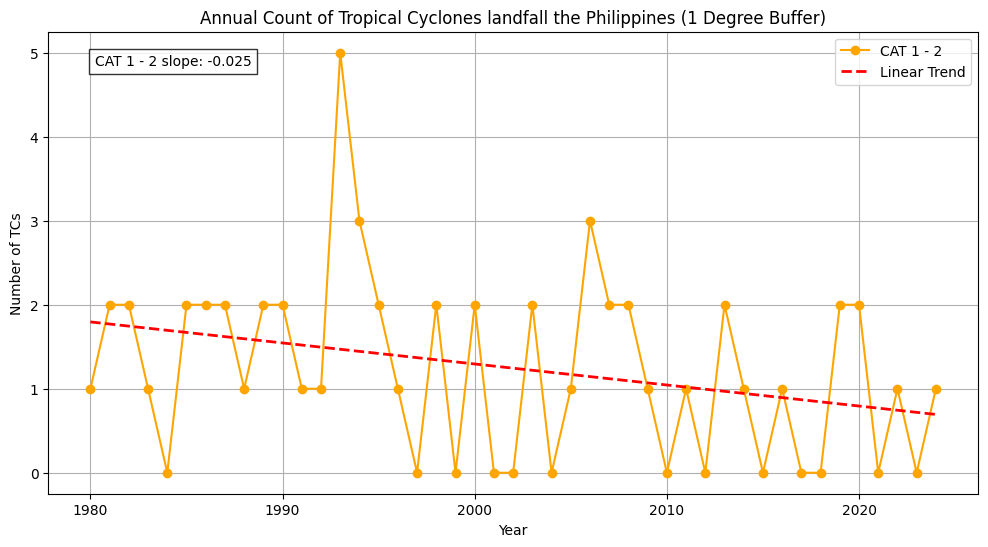

In [92]:
plt.figure(figsize=(12, 6))
plt.plot(landfall_counts.index, landfall_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='o', color='orange')
plt.title('Annual Count of Tropical Cyclones landfall the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(landfall_counts.index, landfall_counts['CAT 1 - 2'], 1)
p = np.poly1d(z)
plt.plot(landfall_counts.index, p(landfall_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_cat1_3 = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'CAT 1 - 2 slope: {slope_cat1_3B:.3f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()

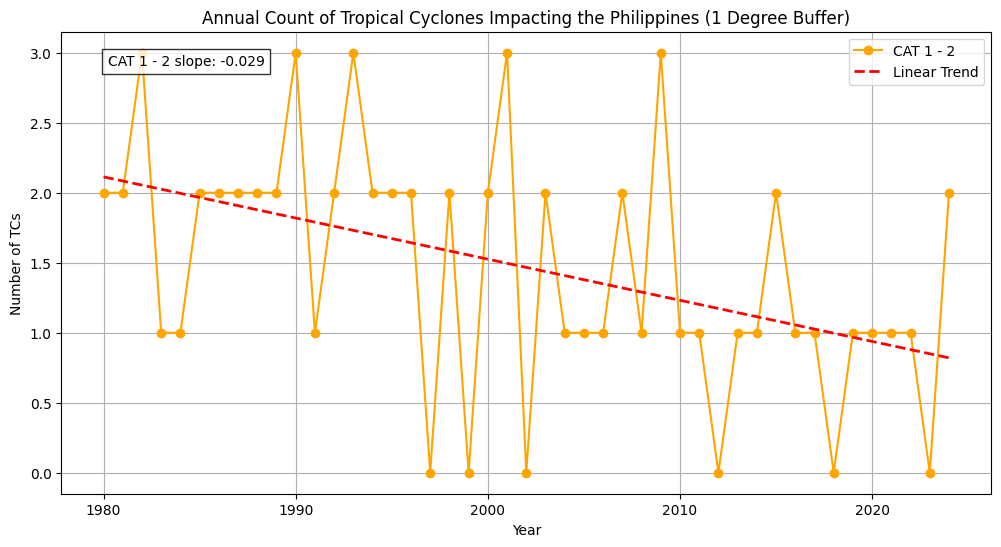

In [93]:
plt.figure(figsize=(12, 6))
plt.plot(impacting_counts.index, impacting_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='o', color='orange')
plt.title('Annual Count of Tropical Cyclones Impacting the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['CAT 1 - 2'], 1)
p = np.poly1d(z)
plt.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_cat1_3 = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'CAT 1 - 2 slope: {slope_cat1_3:.3f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()

In [94]:
print(f"TS + TD slope: {slope_cat4_5:.3f}")

TS + TD slope: 0.010


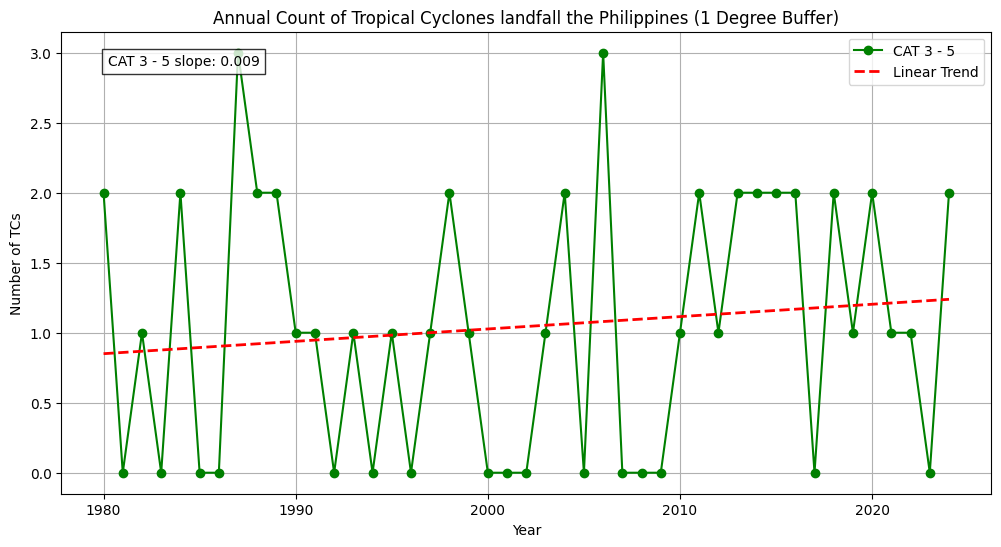

In [95]:
plt.figure(figsize=(12, 6))
plt.plot(landfall_counts.index, landfall_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='o', color='green')
plt.title('Annual Count of Tropical Cyclones landfall the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(landfall_counts.index, landfall_counts['CAT 3 - 5'], 1)
p = np.poly1d(z)
plt.plot(landfall_counts.index, p(landfall_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_cat4_5 = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'CAT 3 - 5 slope: {slope_cat4_5C:.3f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()

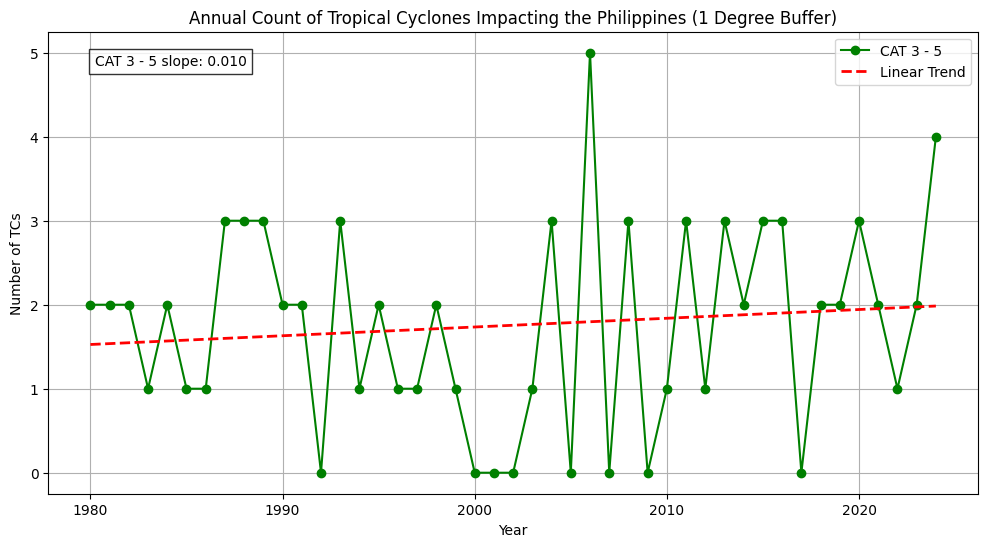

In [96]:
plt.figure(figsize=(12, 6))
plt.plot(impacting_counts.index, impacting_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='o', color='green')
plt.title('Annual Count of Tropical Cyclones Impacting the Philippines (1 Degree Buffer)')

# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['CAT 3 - 5'], 1)
p = np.poly1d(z)
plt.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

# Add slope to the plot
slope_cat4_5 = z[0]  # Slope from polyfit
plt.text(0.05, 0.95, f'CAT 3 - 5 slope: {slope_cat4_5:.3f}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Year')
plt.ylabel('Number of TCs')
plt.legend()
plt.grid(True)
plt.show()

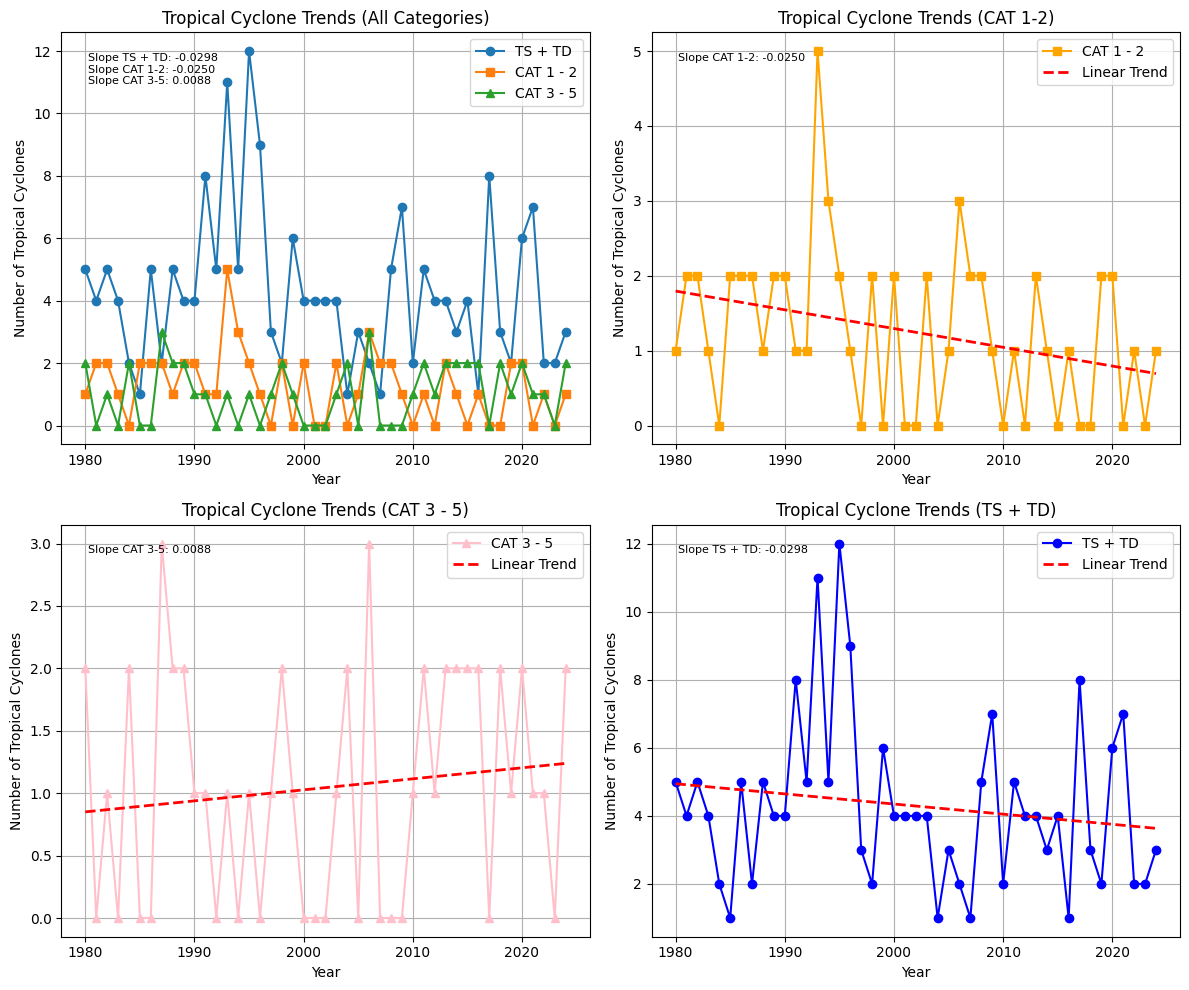

Slopes of the trend lines:
TS + TD: -0.0298
CAT 1-2: -0.0250 
CAT 3-5: 0.0088 


In [97]:
# Create figure with 4 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: TS + TD, CAT 1-2, CAT 3-5
ax1.plot(landfall_counts.index, landfall_counts['TS + TD'], label='TS + TD', marker='o')
ax1.plot(landfall_counts.index, landfall_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='s')
ax1.plot(landfall_counts.index, landfall_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='^')
ax1.set_title('Tropical Cyclone Trends (All Categories)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Tropical Cyclones')
ax1.legend()
ax1.grid(True)

# Calculate slopes for Plot 1
slope_ts_td = calculate_slope(landfall_counts.index, landfall_counts['TS + TD'])
slope_cat1_3 = calculate_slope(landfall_counts.index, landfall_counts['CAT 1 - 2'])
slope_cat4_5 = calculate_slope(landfall_counts.index, landfall_counts['CAT 3 - 5'])
ax1.text(0.05, 0.95, f'Slope TS + TD: {slope_ts_td:.4f}\nSlope CAT 1-2: {slope_cat1_3:.4f}\nSlope CAT 3-5: {slope_cat4_5:.4f}',
         transform=ax1.transAxes, fontsize=8, verticalalignment='top')

# Plot 2: CAT 1-2 only
ax2.plot(landfall_counts.index, landfall_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='s', color='orange')
ax2.set_title('Tropical Cyclone Trends (CAT 1-2)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Tropical Cyclones')
# Calculate linear trend
z = np.polyfit(landfall_counts.index, landfall_counts['CAT 1 - 2'], 1)
p = np.poly1d(z)
ax2.plot(landfall_counts.index, p(landfall_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')
ax2.legend()
ax2.grid(True)
ax2.text(0.05, 0.95, f'Slope CAT 1-2: {slope_cat1_3B:.4f}', transform=ax2.transAxes, fontsize=8, verticalalignment='top')

# Plot 3: CAT 3 - 5 only
ax3.plot(landfall_counts.index, landfall_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='^', color='pink')
ax3.set_title('Tropical Cyclone Trends (CAT 3 - 5)')
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Tropical Cyclones')
# Calculate linear trend
z = np.polyfit(landfall_counts.index, landfall_counts['CAT 3 - 5'], 1)
p = np.poly1d(z)
ax3.plot(landfall_counts.index, p(landfall_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

ax3.legend()
ax3.grid(True)
ax3.text(0.05, 0.95, f'Slope CAT 3-5: {slope_cat4_5C:.4f}', transform=ax3.transAxes, fontsize=8, verticalalignment='top')

# Plot 4: TS + TD only
ax4.plot(landfall_counts.index, landfall_counts['TS + TD'], label='TS + TD', marker='o', color='blue')
ax4.set_title('Tropical Cyclone Trends (TS + TD)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Tropical Cyclones')
# Calculate linear trend
z = np.polyfit(landfall_counts.index, landfall_counts['TS + TD'], 1)
p = np.poly1d(z)
ax4.plot(landfall_counts.index, p(landfall_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

ax4.legend()
ax4.grid(True)
ax4.text(0.05, 0.95, f'Slope TS + TD: {slope_ts_tdA:.4f}', transform=ax4.transAxes, fontsize=8, verticalalignment='top')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

# Print slopes
print("Slopes of the trend lines:")
print(f"TS + TD: {slope_ts_tdA:.4f}")
print(f"CAT 1-2: {slope_cat1_3B:.4f} ")
print(f"CAT 3-5: {slope_cat4_5C:.4f} ")

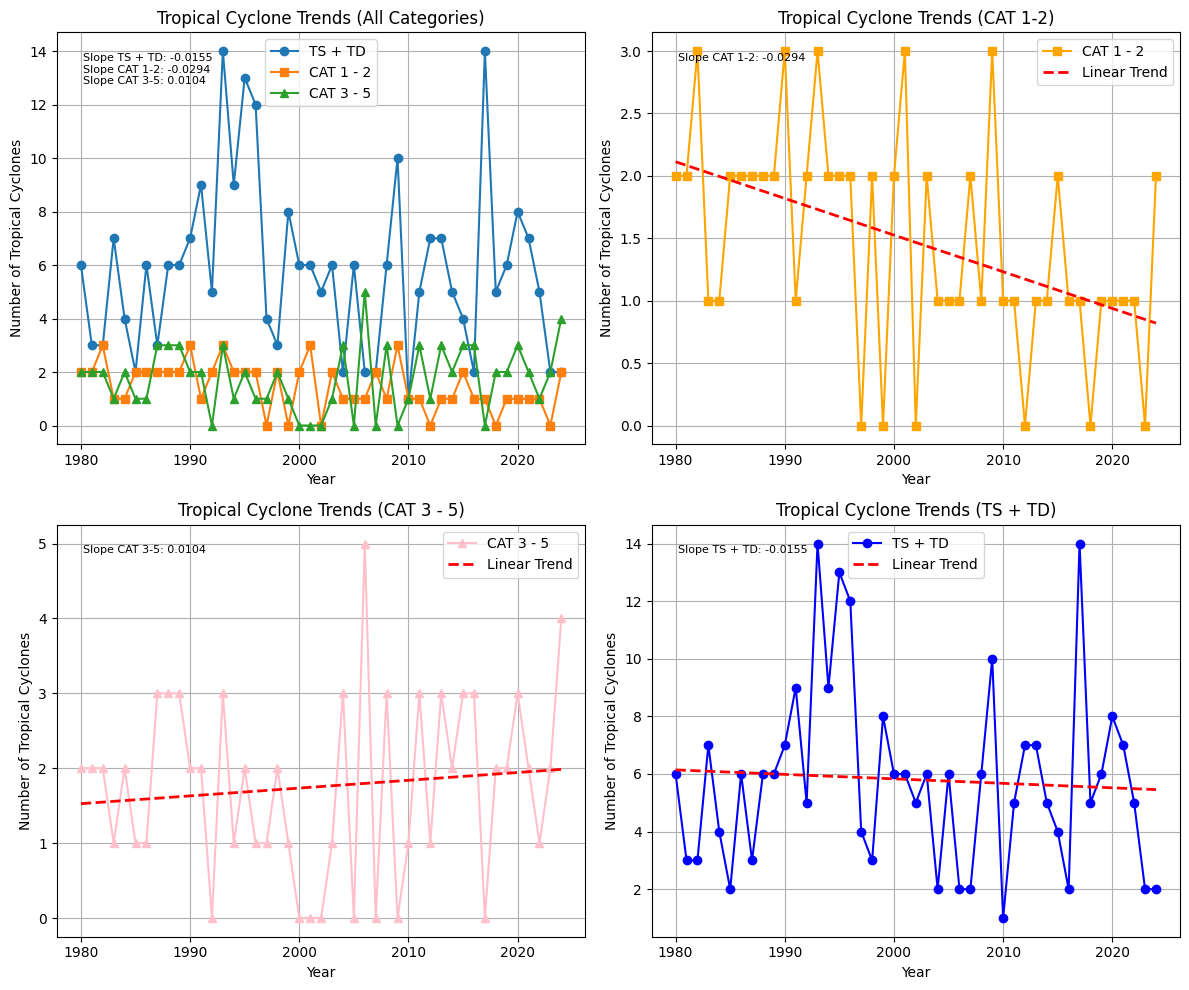

Slopes of the trend lines:
TS + TD: -0.0155
CAT 1-2: -0.0294 
CAT 3-5: 0.0104 


In [98]:
# Create figure with 4 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: TS + TD, CAT 1-2, CAT 3-5
ax1.plot(impacting_counts.index, impacting_counts['TS + TD'], label='TS + TD', marker='o')
ax1.plot(impacting_counts.index, impacting_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='s')
ax1.plot(impacting_counts.index, impacting_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='^')
ax1.set_title('Tropical Cyclone Trends (All Categories)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Tropical Cyclones')
ax1.legend()
ax1.grid(True)

# Calculate slopes for Plot 1
slope_ts_td = calculate_slope(impacting_counts.index, impacting_counts['TS + TD'])
slope_cat1_3 = calculate_slope(impacting_counts.index, impacting_counts['CAT 1 - 2'])
slope_cat4_5 = calculate_slope(impacting_counts.index, impacting_counts['CAT 3 - 5'])
ax1.text(0.05, 0.95, f'Slope TS + TD: {slope_ts_td:.4f}\nSlope CAT 1-2: {slope_cat1_3:.4f}\nSlope CAT 3-5: {slope_cat4_5:.4f}',
         transform=ax1.transAxes, fontsize=8, verticalalignment='top')

# Plot 2: CAT 1-2 only
ax2.plot(impacting_counts.index, impacting_counts['CAT 1 - 2'], label='CAT 1 - 2', marker='s', color='orange')
ax2.set_title('Tropical Cyclone Trends (CAT 1-2)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Tropical Cyclones')
# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['CAT 1 - 2'], 1)
p = np.poly1d(z)
ax2.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')
ax2.legend()
ax2.grid(True)
ax2.text(0.05, 0.95, f'Slope CAT 1-2: {slope_cat1_3:.4f}', transform=ax2.transAxes, fontsize=8, verticalalignment='top')

# Plot 3: CAT 3 - 5 only
ax3.plot(impacting_counts.index, impacting_counts['CAT 3 - 5'], label='CAT 3 - 5', marker='^', color='pink')
ax3.set_title('Tropical Cyclone Trends (CAT 3 - 5)')
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Tropical Cyclones')
# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['CAT 3 - 5'], 1)
p = np.poly1d(z)
ax3.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

ax3.legend()
ax3.grid(True)
ax3.text(0.05, 0.95, f'Slope CAT 3-5: {slope_cat4_5:.4f}', transform=ax3.transAxes, fontsize=8, verticalalignment='top')

# Plot 4: TS + TD only
ax4.plot(impacting_counts.index, impacting_counts['TS + TD'], label='TS + TD', marker='o', color='blue')
ax4.set_title('Tropical Cyclone Trends (TS + TD)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Number of Tropical Cyclones')
# Calculate linear trend
z = np.polyfit(impacting_counts.index, impacting_counts['TS + TD'], 1)
p = np.poly1d(z)
ax4.plot(impacting_counts.index, p(impacting_counts.index),
         color='red', linestyle='--', linewidth=2, label='Linear Trend')

ax4.legend()
ax4.grid(True)
ax4.text(0.05, 0.95, f'Slope TS + TD: {slope_ts_td:.4f}', transform=ax4.transAxes, fontsize=8, verticalalignment='top')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

# Print slopes
print("Slopes of the trend lines:")
print(f"TS + TD: {slope_ts_td:.4f}")
print(f"CAT 1-2: {slope_cat1_3:.4f} ")
print(f"CAT 3-5: {slope_cat4_5:.4f} ")